# Un marcapasos sin cirugía: ultrasonido + un canal bacteriano

:::{image} figuras/pixabot.png
:alt: Pixabot mascot
:width: 80px
:align: center
:figclass: pixabot-mascot
:::

**~30 veces.** Eso es cuánto sube el calcio dentro de una célula del corazón cuando le aplicas ultrasonido — sin tocarla, sin abrirla, sin cables.

¿Te imaginas un marcapasos que va por fuera de la piel?

---

**Paper:** [A wearable non-invasive sonogenetic pacemaker](https://doi.org/10.1038/s41551-026-01673-z)
**Journal:** *Nature Biomedical Engineering*, 2 de junio de 2026
**Video corto:** [Ver en YouTube](https://youtube.com/shorts/TNdsZPuM3Aw)

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Ciencia-a-Mordiscos/lab/blob/main/papers/2026-06-02-marcapasos-ultrasonico-sonogenetico/notebook.ipynb)


## El problema con los marcapasos de hoy

Un marcapasos tradicional necesita cirugía: abren el pecho, meten cables (electrodos) que tocan el corazón, y los conectan a una batería bajo la piel. Funciona — pero infecciones, daño a la vena, falla de los cables y reemplazo de la batería son riesgos reales.

Lo que un equipo en *Nature Biomedical Engineering* mostró este 2 de junio: marcar el ritmo del corazón **sin tocarlo**. Solo un parche de ultrasonido sobre el pecho.

El truco está en una proteína prestada de una bacteria — un canal mecanosensible llamado MscL-G22S — que reacciona a las ondas de presión del ultrasonido. Al meter ese canal en las células del corazón con terapia génica, las células se vuelven "escuchables": el ultrasonido las abre, entra calcio, y la célula late.

Veamos qué tan fuerte es ese efecto.

In [1]:
# ══════════════════════════════════════════════════════════════
# Configuración — modifica estos valores para explorar
# ══════════════════════════════════════════════════════════════
PRESION_UMBRAL = 1.6       # MPa — donde el éxito cruza el 50%
PRESION_SATURACION = 2.2   # MPa — donde casi todos los ciclos pacean
FUENTE = 'Fuente: Wei et al. (2026), Nature Biomedical Engineering | Datos: Source Data Fig. 2-3'
COLOR_DATOS = '#2563EB'      # azul CaM
COLOR_ALERTA = '#DC2626'     # rojo
COLOR_SECUNDARIO = '#059669' # verde emerald
COLOR_REFERENCIA = '#D97706' # ámbar
COLOR_CONTEXTO = '#BBBBBB'   # gris
COLOR_VIOLETA = '#7C3AED'

import os, urllib.request
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

# Estilo CaM
style_file = '../../cam.mplstyle'
if not os.path.exists(style_file):
    style_file = '/tmp/cam.mplstyle'
    if not os.path.exists(style_file):
        urllib.request.urlretrieve(
            'https://raw.githubusercontent.com/Ciencia-a-Mordiscos/lab/main/cam.mplstyle',
            style_file)
plt.style.use(style_file)

# Cargar los 3 datasets que liberaron como Source Data
DATA_DIR = 'datos' if os.path.exists('datos') else '/home/jupyter/datos'
calcio = pd.read_csv(f'{DATA_DIR}/calcio_in_vitro.csv')
dosis = pd.read_csv(f'{DATA_DIR}/curva_dosis_respuesta.csv')
intervalos = pd.read_csv(f'{DATA_DIR}/intervalos_off_on.csv')

print(f'Calcio in vitro: {len(calcio)} células, {calcio["group"].nunique()} grupos experimentales')
print(f'Dosis-respuesta: {len(dosis)} mediciones, {dosis["acoustic_pressure_mpa"].nunique()} presiones × {dosis["pulse_duration_ms"].nunique()} duraciones')
print(f'Intervalos in vivo: {len(intervalos)} latidos, {intervalos["trial"].nunique()} trials de rata')

Calcio in vitro: 172 células, 4 grupos experimentales
Dosis-respuesta: 180 mediciones, 6 presiones × 5 duraciones
Intervalos in vivo: 97 latidos, 7 trials de rata


## Lo que la célula hace cuando llega el ultrasonido

Aquí está.

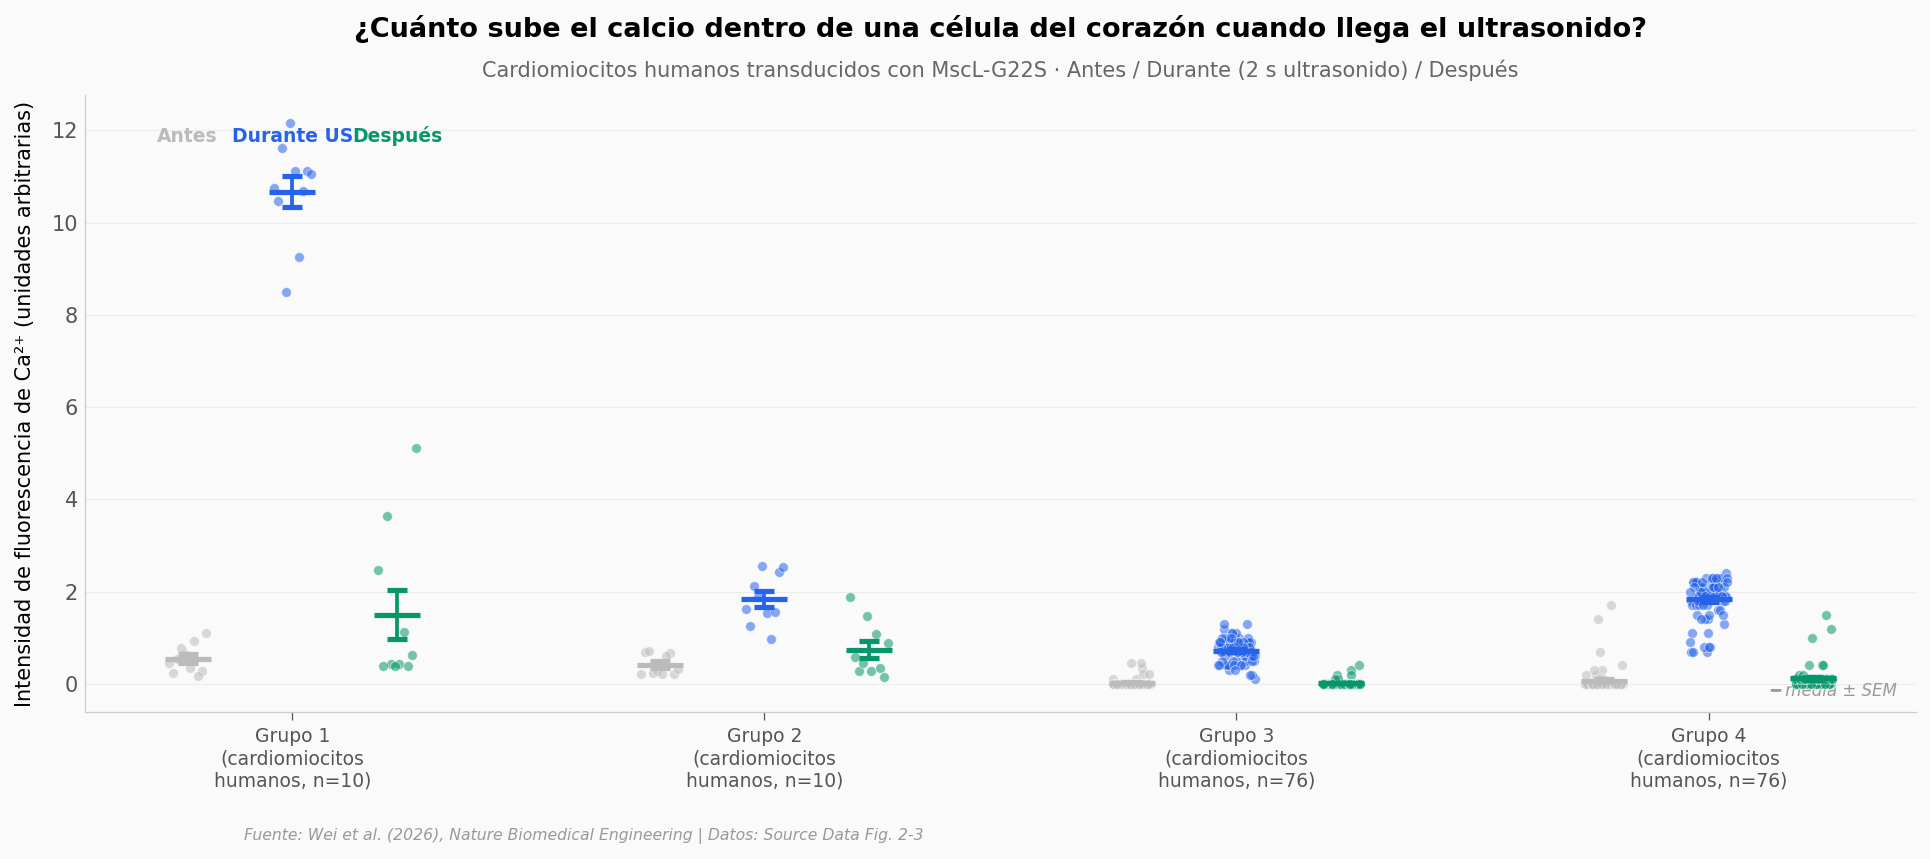


Fold change durante/antes por grupo:
  left_a: fold=19.5× | Wilcoxon p=1.95e-03 | Cohen's d pareado=9.74
  left_b: fold=4.4× | Wilcoxon p=1.95e-03 | Cohen's d pareado=2.57
  right_a: fold=29.1× | Wilcoxon p=3.30e-14 | Cohen's d pareado=2.76
  right_b: fold=25.8× | Wilcoxon p=3.40e-14 | Cohen's d pareado=3.62


In [2]:
# Gráfica hero: respuesta de calcio pre / durante / post ultrasonido
# por cada grupo experimental — los 4 paneles del Figure 2 del paper

fig, ax = plt.subplots(figsize=(13, 5.5))

# Orden de grupos y posiciones en el eje X (gap entre grupos)
grupos = ['left_a', 'left_b', 'right_a', 'right_b']
etiquetas_grupo = ['Grupo 1\n(cardiomiocitos\nhumanos, n=10)', 'Grupo 2\n(cardiomiocitos\nhumanos, n=10)',
                   'Grupo 3\n(cardiomiocitos\nhumanos, n=76)', 'Grupo 4\n(cardiomiocitos\nhumanos, n=76)']
fases = ['pre', 'during', 'post']
fase_labels = ['Antes', 'Durante US', 'Después']
fase_colors = [COLOR_CONTEXTO, COLOR_DATOS, COLOR_SECUNDARIO]

np.random.seed(42)  # jitter reproducible
positions_x = []
xtick_pos = []
for gi, grupo in enumerate(grupos):
    base_x = gi * 4.5  # gap de 4.5 entre grupos
    xtick_pos.append(base_x + 1.0)
    sub = calcio[calcio['group'] == grupo]
    n = len(sub)
    for fi, fase in enumerate(fases):
        pos = base_x + fi * 1.0
        positions_x.append(pos)
        vals = sub[fase].values
        # Jitter horizontal reproducible
        x_strip = np.linspace(pos - 0.18, pos + 0.18, n)
        np.random.shuffle(x_strip)
        ax.scatter(x_strip, vals, color=fase_colors[fi], s=22, alpha=0.55,
                   edgecolors='white', linewidths=0.4, zorder=5)
        # Media ± SEM
        mean = vals.mean()
        sem = vals.std(ddof=1) / np.sqrt(n)
        ax.errorbar(pos, mean, yerr=sem, fmt='_', color=fase_colors[fi],
                    markersize=22, markeredgewidth=2.5,
                    capsize=5, capthick=1.5, zorder=6)

# Etiquetas inline de las fases en el primer grupo
for fi, lbl in enumerate(fase_labels):
    ax.text(fi * 1.0, ax.get_ylim()[1] * 0.92, lbl, fontsize=9,
            color=fase_colors[fi], fontweight='bold', ha='center')

ax.set_xticks(xtick_pos)
ax.set_xticklabels(etiquetas_grupo, fontsize=9)
ax.set_ylabel('Intensidad de fluorescencia de Ca²⁺ (unidades arbitrarias)', fontsize=10)
ax.set_title('¿Cuánto sube el calcio dentro de una célula del corazón cuando llega el ultrasonido?',
             fontsize=13, fontweight='bold', pad=28)
ax.text(0.5, 1.03, 'Cardiomiocitos humanos transducidos con MscL-G22S · Antes / Durante (2 s ultrasonido) / Después',
        transform=ax.transAxes, fontsize=10, color='#666666', ha='center')

# Nota de error bars
ax.text(0.99, 0.02, '━ media ± SEM', transform=ax.transAxes,
        fontsize=8, color='#999999', ha='right', va='bottom', style='italic')

fig.text(0.13, -0.03, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.tight_layout()
plt.savefig('figuras/calcio_in_vitro.png', dpi=200, bbox_inches='tight')
plt.show()

# Cálculo del fold para cada grupo (lo usaremos en la lectura guiada)
print('\nFold change durante/antes por grupo:')
for grupo in grupos:
    sub = calcio[calcio['group'] == grupo]
    fold = sub['during'].mean() / sub['pre'].mean()
    # Wilcoxon pareado (durante vs antes)
    w_stat, w_p = stats.wilcoxon(sub['during'], sub['pre'])
    # Cohen's d pareado
    diff = sub['during'] - sub['pre']
    d = diff.mean() / diff.std(ddof=1)
    print(f'  {grupo}: fold={fold:.1f}× | Wilcoxon p={w_p:.2e} | Cohen\'s d pareado={d:.2f}')

**El patrón es muy fuerte.** En los 4 grupos, la fluorescencia de calcio durante el ultrasonido sube entre 4 y 29 veces respecto al estado basal — y baja de nuevo cuando el ultrasonido se apaga.

Los tamaños del efecto son enormes. Cohen's d pareado va de 2.6 a 9.7 según el grupo. Para referencia: en biomedicina un efecto "grande" empieza en 0.8. Aquí estamos en otra escala.

Eso es lo importante: el canal MscL-G22S responde al ultrasonido. La célula entra calcio, contrae, y vuelve a su estado en cuanto el estímulo termina. Sin daño aparente.

## ¿Cuánta presión hace falta?

Saber que el ultrasonido funciona no es suficiente. Para un dispositivo wearable hay que saber **cuánta presión acústica** necesitas — porque demasiado poca y la célula no responde, demasiada y puedes dañar tejido.

El equipo barrió presiones de 1.2 a 2.2 MPa y duraciones de pulso de 10 a 80 ms, y midió la tasa de éxito del pacing en cada combinación.

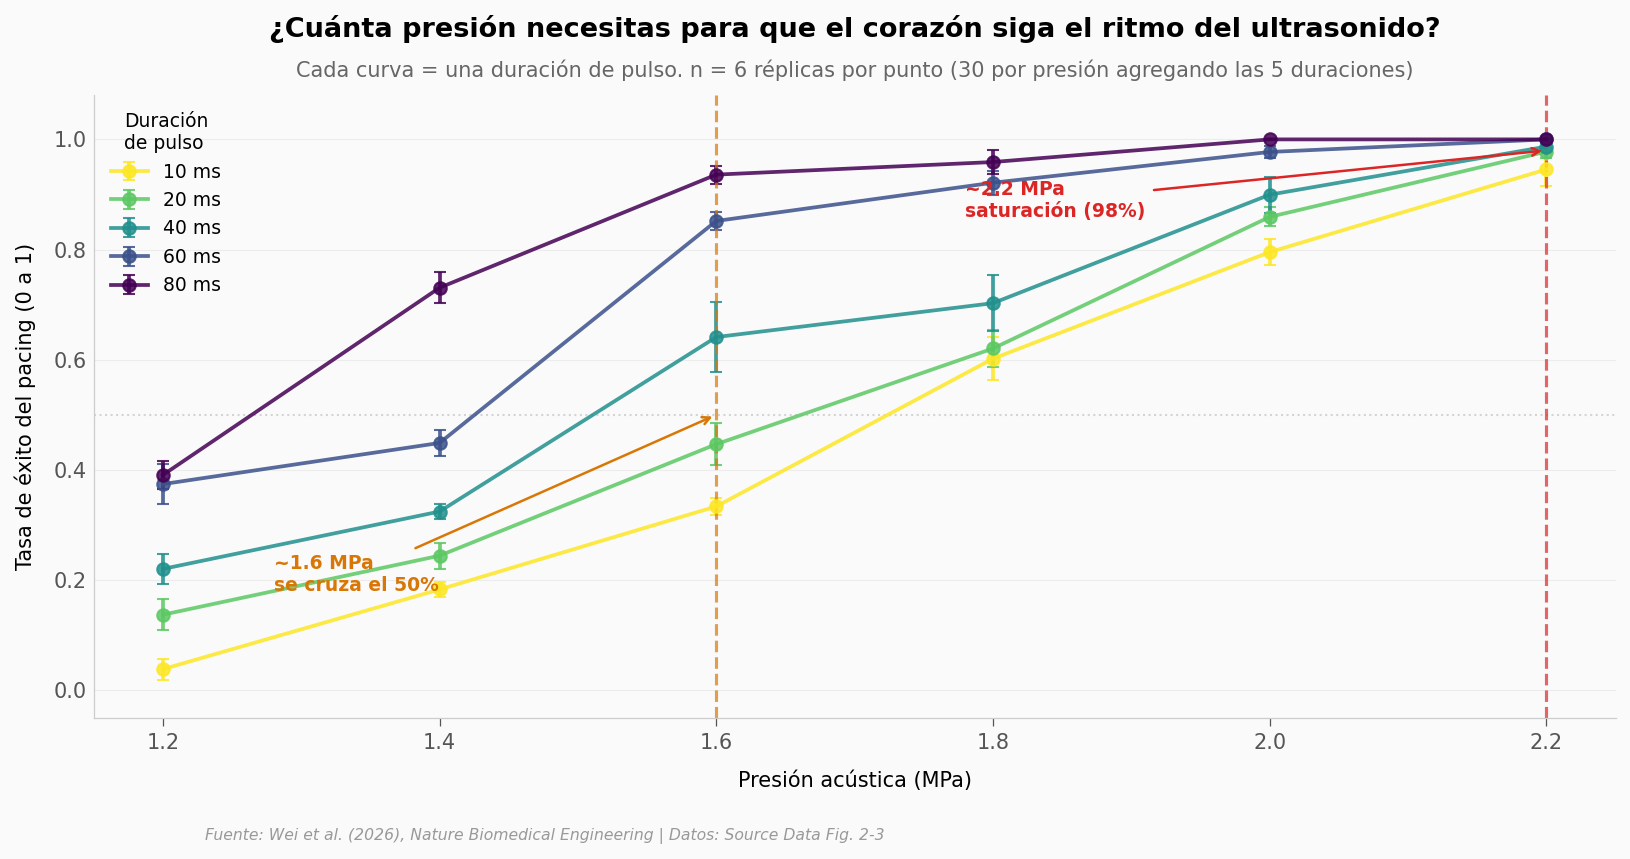


Éxito medio por presión acústica (todas las duraciones):
  1.2 MPa: éxito = 0.232 ± 0.152  (n=30)
  1.4 MPa: éxito = 0.386 ± 0.203  (n=30)
  1.6 MPa: éxito = 0.642 ± 0.247  (n=30)
  1.8 MPa: éxito = 0.761 ± 0.173  (n=30)
  2.0 MPa: éxito = 0.906 ± 0.089  (n=30)
  2.2 MPa: éxito = 0.982 ± 0.040  (n=30)


In [3]:
# Curva dosis-respuesta: éxito vs presión, con colores por duración de pulso

fig, ax = plt.subplots(figsize=(11, 5.5))

# Agregamos por (presión, duración) para obtener la media de las réplicas
agregado = dosis.groupby(['acoustic_pressure_mpa', 'pulse_duration_ms']).agg(
    success=('success_rate', 'mean'),
    sem=('success_rate', lambda x: x.std(ddof=1) / np.sqrt(len(x))),
    n=('success_rate', 'count')
).reset_index()

duraciones = sorted(agregado['pulse_duration_ms'].unique())
cmap = plt.cm.viridis_r
colors_dur = [cmap(i / max(1, len(duraciones) - 1)) for i in range(len(duraciones))]

for i, dur in enumerate(duraciones):
    sub = agregado[agregado['pulse_duration_ms'] == dur].sort_values('acoustic_pressure_mpa')
    ax.errorbar(sub['acoustic_pressure_mpa'], sub['success'], yerr=sub['sem'],
                marker='o', markersize=6, linewidth=1.8, capsize=3,
                color=colors_dur[i], label=f'{int(dur)} ms', alpha=0.85)

# Líneas de referencia: umbral 50% y saturación
ax.axhline(y=0.5, color=COLOR_CONTEXTO, linewidth=1, linestyle=':', alpha=0.6)
ax.axvline(x=PRESION_UMBRAL, color=COLOR_REFERENCIA, linewidth=1.5, linestyle='--', alpha=0.7)
ax.annotate(f'~{PRESION_UMBRAL} MPa\nse cruza el 50%',
            xy=(PRESION_UMBRAL, 0.5), xytext=(PRESION_UMBRAL - 0.32, 0.18),
            fontsize=9, fontweight='bold', color=COLOR_REFERENCIA,
            arrowprops=dict(arrowstyle='->', color=COLOR_REFERENCIA, lw=1.2))
ax.axvline(x=PRESION_SATURACION, color=COLOR_ALERTA, linewidth=1.5, linestyle='--', alpha=0.7)
ax.annotate(f'~{PRESION_SATURACION} MPa\nsaturación (98%)',
            xy=(PRESION_SATURACION, 0.98), xytext=(PRESION_SATURACION - 0.42, 0.86),
            fontsize=9, fontweight='bold', color=COLOR_ALERTA,
            arrowprops=dict(arrowstyle='->', color=COLOR_ALERTA, lw=1.2))

ax.set_xlabel('Presión acústica (MPa)', fontsize=10)
ax.set_ylabel('Tasa de éxito del pacing (0 a 1)', fontsize=10)
ax.set_ylim(-0.05, 1.08)
ax.set_title('¿Cuánta presión necesitas para que el corazón siga el ritmo del ultrasonido?',
             fontsize=13, fontweight='bold', pad=28)
ax.text(0.5, 1.03, 'Cada curva = una duración de pulso. n = 6 réplicas por punto (30 por presión agregando las 5 duraciones)',
        transform=ax.transAxes, fontsize=10, color='#666666', ha='center')
ax.legend(title='Duración\nde pulso', fontsize=9, title_fontsize=9,
          loc='upper left', framealpha=0.9)

fig.text(0.13, -0.03, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.tight_layout()
plt.savefig('figuras/dosis_respuesta.png', dpi=200, bbox_inches='tight')
plt.show()

# Estadísticos resumen por presión (agregando duraciones)
print('\nÉxito medio por presión acústica (todas las duraciones):')
por_presion = dosis.groupby('acoustic_pressure_mpa')['success_rate'].agg(['mean', 'std', 'count'])
for p, row in por_presion.iterrows():
    print(f'  {p} MPa: éxito = {row["mean"]:.3f} ± {row["std"]:.3f}  (n={int(row["count"])})')

## Del plato al animal

Los datos de calcio son in vitro: células en una placa. El siguiente paso del paper fue probarlo en un animal vivo — ratas a las que les inyectaron el virus con el canal MscL-G22S en el corazón.

La métrica clave aquí es el **intervalo entre latidos** medido durante 3 ventanas: antes del ultrasonido (ritmo natural), durante el ultrasonido (ritmo forzado por el dispositivo), y después (vuelta al ritmo natural).

Nota: el paper reporta 7 trials in vivo. Los datos publicados como Source Data son comparables solo para 3 (trials j, k, n) — los otros 4 usan métricas distintas (amplitudes con signo, intervalos en segundos vs milisegundos) que no son comparables en el mismo eje. Trabajamos con los 3 limpios.

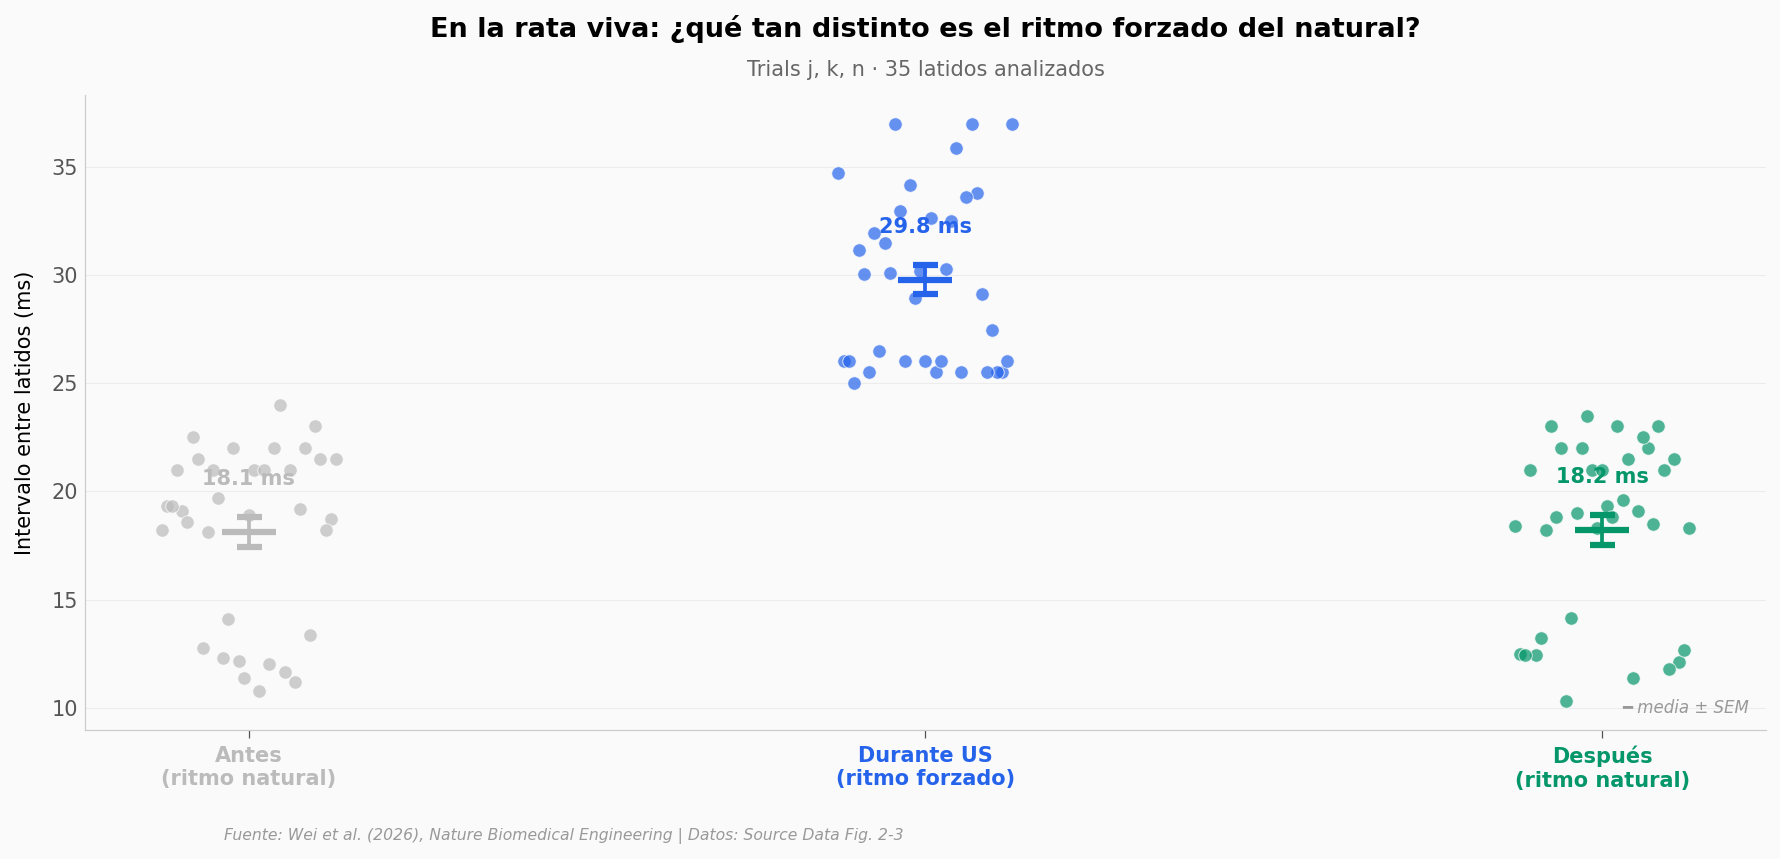


Durante US vs Antes (Wilcoxon pareado, una cola): p = 1.23e-07
Razón media ON / OFF = 1.64× (intervalos ON son 64% más largos)
Cohen's d pareado (ON - OFF_pre) = 1.69


In [4]:
# Intervalos OFF / ON / OFF en ratas in vivo (3 trials limpios)

# Filtrar a los 3 trials comparables
trials_limpios = ['trial_j', 'trial_k', 'trial_n']
iv = intervalos[intervalos['trial'].isin(trials_limpios)].copy()
# Convertir a ms para visualización
iv['off_pre_ms']    = iv['off_pre_s']    * 1000.0
iv['on_during_ms']  = iv['on_during_s']  * 1000.0
iv['off_post_ms']   = iv['off_post_s']   * 1000.0

fig, ax = plt.subplots(figsize=(12, 5.5))

# Posiciones X: una columna por fase, separadas por trial
fases = ['off_pre_ms', 'on_during_ms', 'off_post_ms']
fase_labels = ['Antes\n(ritmo natural)', 'Durante US\n(ritmo forzado)', 'Después\n(ritmo natural)']
fase_colors = [COLOR_CONTEXTO, COLOR_DATOS, COLOR_SECUNDARIO]
positions = [0, 1.4, 2.8]

np.random.seed(42)
for fi, fase in enumerate(fases):
    vals = iv[fase].values
    n = len(vals)
    x_strip = np.linspace(positions[fi] - 0.18, positions[fi] + 0.18, n)
    np.random.shuffle(x_strip)
    ax.scatter(x_strip, vals, color=fase_colors[fi], s=42, alpha=0.7,
               edgecolors='white', linewidths=0.5, zorder=5)
    mean = vals.mean()
    sem = vals.std(ddof=1) / np.sqrt(n)
    ax.errorbar(positions[fi], mean, yerr=sem, fmt='_', color=fase_colors[fi],
                markersize=26, markeredgewidth=3,
                capsize=6, capthick=1.7, zorder=6)
    # Etiqueta de la media
    ax.text(positions[fi], mean + sem + 1.5, f'{mean:.1f} ms',
            fontsize=10, fontweight='bold', color=fase_colors[fi],
            ha='center', zorder=7)

ax.set_xticks(positions)
ax.set_xticklabels(fase_labels, fontsize=10, fontweight='bold')
for tick, color in zip(ax.get_xticklabels(), fase_colors):
    tick.set_color(color)

ax.set_ylabel('Intervalo entre latidos (ms)', fontsize=10)
ax.set_title('En la rata viva: ¿qué tan distinto es el ritmo forzado del natural?',
             fontsize=13, fontweight='bold', pad=28)
ax.text(0.5, 1.03, f'Trials j, k, n · {len(iv)} latidos analizados',
        transform=ax.transAxes, fontsize=10, color='#666666', ha='center')

# Nota de error bars + n
ax.text(0.99, 0.02, '━ media ± SEM', transform=ax.transAxes,
        fontsize=8, color='#999999', ha='right', va='bottom', style='italic')

fig.text(0.13, -0.03, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.tight_layout()
plt.savefig('figuras/intervalos_in_vivo.png', dpi=200, bbox_inches='tight')
plt.show()

# Test de Wilcoxon pareado: ON > OFF (pre)
w_stat, w_p = stats.wilcoxon(iv['on_during_ms'], iv['off_pre_ms'], alternative='greater')
fold = iv['on_during_ms'].mean() / iv['off_pre_ms'].mean()
# Cohen's d pareado
diff = iv['on_during_ms'] - iv['off_pre_ms']
d = diff.mean() / diff.std(ddof=1)
print(f'\nDurante US vs Antes (Wilcoxon pareado, una cola): p = {w_p:.2e}')
print(f'Razón media ON / OFF = {fold:.2f}× (intervalos ON son {(fold-1)*100:.0f}% más largos)')
print(f'Cohen\'s d pareado (ON - OFF_pre) = {d:.2f}')

## ¿Qué tan separadas están las distribuciones?

Una cosa es ver que la media sube; otra es ver si las distribuciones de intervalos ON y OFF realmente no se traslapan. Si los dos grupos de latidos tienen distribuciones que se cruzan mucho, el efecto "promedio" puede esconder que muchos latidos no respondieron.

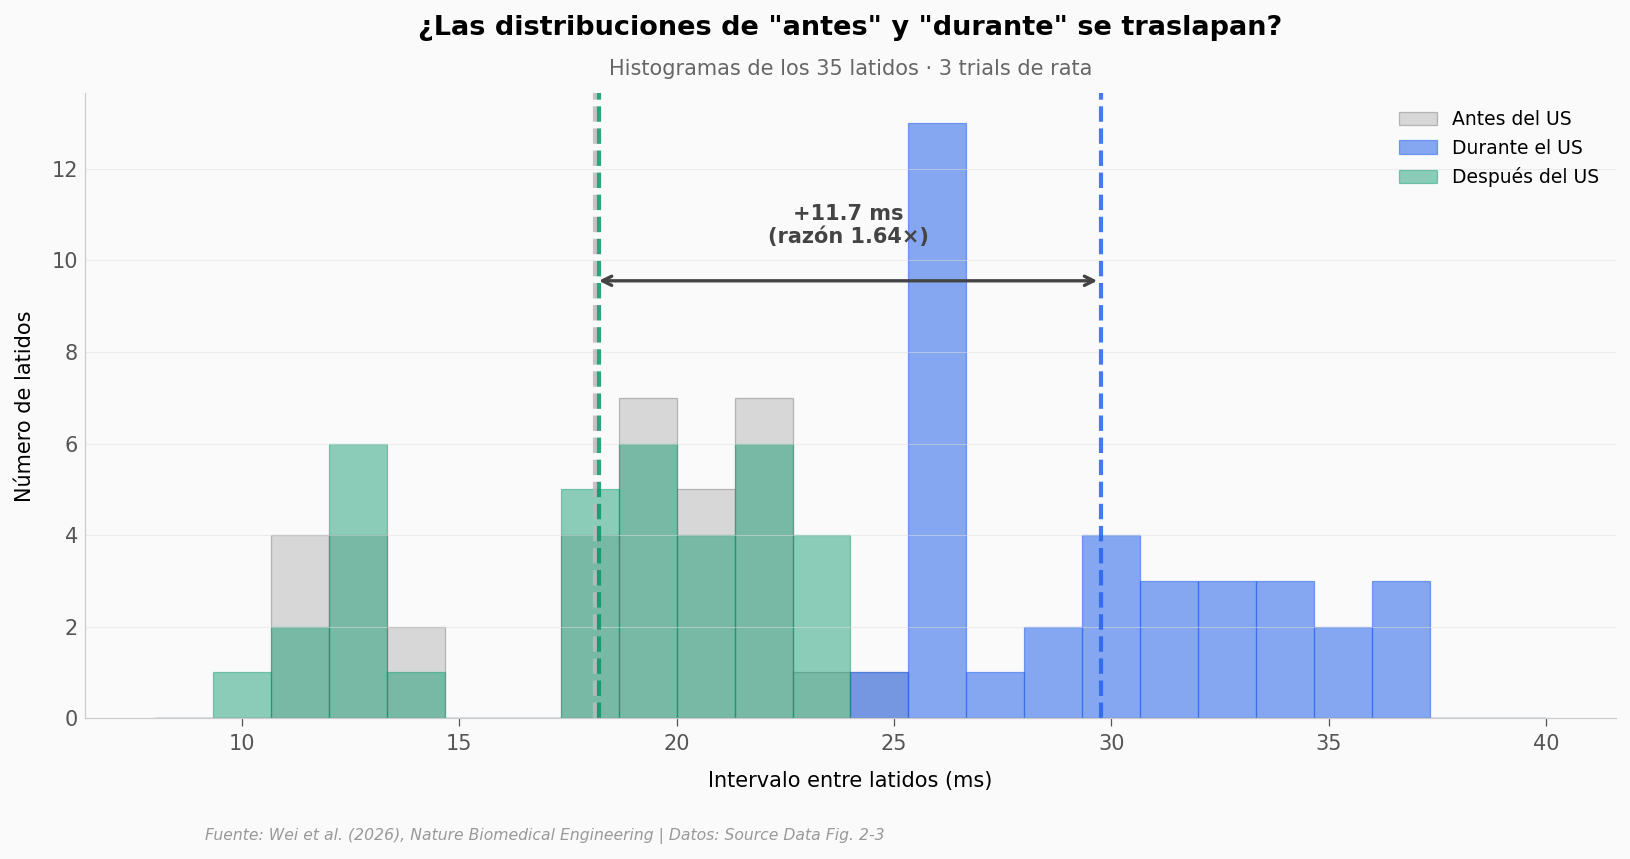


Mann-Whitney (ON > OFF pre, no pareado): U = 1225, p = 3.12e-13
Fracción de latidos ON dentro del rango de OFF pre: 0.0%


In [5]:
# Histograma de intervalos: OFF pre / ON during / OFF post superpuestos

fig, ax = plt.subplots(figsize=(11, 5.5))

# Trabajar con los 3 trials limpios
bins = np.linspace(8, 40, 25)

# OFF pre (gris)
ax.hist(iv['off_pre_ms'], bins=bins, color=COLOR_CONTEXTO, alpha=0.55,
        edgecolor='#888888', linewidth=0.6, label='Antes del US')
# ON during (azul)
ax.hist(iv['on_during_ms'], bins=bins, color=COLOR_DATOS, alpha=0.55,
        edgecolor=COLOR_DATOS, linewidth=0.6, label='Durante el US')
# OFF post (verde)
ax.hist(iv['off_post_ms'], bins=bins, color=COLOR_SECUNDARIO, alpha=0.45,
        edgecolor=COLOR_SECUNDARIO, linewidth=0.6, label='Después del US')

# Líneas verticales con las medias
medias = {
    'Antes': (iv['off_pre_ms'].mean(), COLOR_CONTEXTO),
    'Durante': (iv['on_during_ms'].mean(), COLOR_DATOS),
    'Después': (iv['off_post_ms'].mean(), COLOR_SECUNDARIO),
}
y_max = ax.get_ylim()[1]
for nombre, (m, c) in medias.items():
    ax.axvline(x=m, color=c, linewidth=2, linestyle='--', alpha=0.85)

# Flecha bidireccional entre media OFF pre y media ON during
m_off = medias['Antes'][0]
m_on = medias['Durante'][0]
ax.annotate('', xy=(m_on, y_max * 0.7), xytext=(m_off, y_max * 0.7),
            arrowprops=dict(arrowstyle='<->', color='#444444', lw=1.6))
ax.text((m_off + m_on) / 2, y_max * 0.76,
        f'+{m_on - m_off:.1f} ms\n(razón {m_on/m_off:.2f}×)',
        fontsize=10, fontweight='bold', ha='center', color='#444444')

ax.set_xlabel('Intervalo entre latidos (ms)', fontsize=10)
ax.set_ylabel('Número de latidos', fontsize=10)
ax.set_title('¿Las distribuciones de "antes" y "durante" se traslapan?',
             fontsize=13, fontweight='bold', pad=28)
ax.text(0.5, 1.03, f'Histogramas de los {len(iv)} latidos · 3 trials de rata',
        transform=ax.transAxes, fontsize=10, color='#666666', ha='center')
ax.legend(loc='upper right', fontsize=9, framealpha=0.9)

fig.text(0.13, -0.03, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.tight_layout()
plt.savefig('figuras/histograma_anomalia.png', dpi=200, bbox_inches='tight')
plt.show()

# Mann-Whitney como check no pareado entre las distribuciones
u_stat, u_p = stats.mannwhitneyu(iv['on_during_ms'], iv['off_pre_ms'], alternative='greater')
print(f'\nMann-Whitney (ON > OFF pre, no pareado): U = {u_stat:.0f}, p = {u_p:.2e}')
# Solapamiento simple: ¿qué fracción de ON está por debajo del máximo de OFF pre?
max_off = iv['off_pre_ms'].max()
solap = (iv['on_during_ms'] <= max_off).mean() * 100
print(f'Fracción de latidos ON dentro del rango de OFF pre: {solap:.1f}%')

## Ahora tú

Los datos están en tu carpeta `datos/`. Algunas preguntas que se pueden responder cambiando UN valor en la configuración de arriba o escribiendo unas líneas:

1. **¿Cuál es el efecto más pequeño?** El grupo `left_b` tiene Cohen's d de 2.57 (vs 9.74 en `left_a`). ¿Por qué será? Comparar las desviaciones estándar de cada fase entre los dos grupos puede dar una pista.

2. **¿La duración del pulso importa más que la presión?** Filtra `dosis` por `pulse_duration_ms == 5` vs `pulse_duration_ms == 30` y compara la pendiente de éxito vs presión.

3. **¿El ritmo vuelve exactamente a donde estaba?** Compara `off_pre_ms` con `off_post_ms` con un Wilcoxon pareado — si la diferencia no es significativa, el dispositivo es reversible. Si sí lo es, hay un efecto residual.

In [6]:
# --- EXPERIMENTA AQUÍ ---
# ¿El ritmo vuelve exactamente al baseline después del ultrasonido?
# Comparamos OFF pre vs OFF post (mismo trial, latido por latido)

w_stat, w_p = stats.wilcoxon(iv['off_post_ms'], iv['off_pre_ms'])
diff_recovery = (iv['off_post_ms'] - iv['off_pre_ms'])
print(f'OFF pre vs OFF post (Wilcoxon pareado): p = {w_p:.3f}')
print(f'Diferencia media post − pre = {diff_recovery.mean():+.2f} ms')
print(f'Cohen\'s d pareado = {diff_recovery.mean() / diff_recovery.std(ddof=1):.2f}')
print(f'\nInterpretación: si p > 0.05, el ritmo "vuelve" al baseline (efecto reversible).')
print(f'Si p < 0.05, hay un efecto residual aunque sea pequeño.')

OFF pre vs OFF post (Wilcoxon pareado): p = 0.511
Diferencia media post − pre = +0.09 ms
Cohen's d pareado = 0.08

Interpretación: si p > 0.05, el ritmo "vuelve" al baseline (efecto reversible).
Si p < 0.05, hay un efecto residual aunque sea pequeño.


## Lo que los datos soportan

| Afirmación | ¿Soportada? | Detalle |
|------------|-------------|---------|
| El ultrasonido eleva el calcio dentro de cardiomiocitos transducidos con MscL-G22S | ✅ | 4 grupos in vitro, fold de 4 a 29×, Cohen's d pareado 2.6 a 9.7, Wilcoxon p ≤ 10⁻³ en todos |
| El sistema sigue una curva dosis-respuesta con umbral en ~1.6 MPa y saturación en ~2.2 MPa | ✅ | Éxito medio sube de 0.23 (1.2 MPa) a 0.98 (2.2 MPa), 30 réplicas por punto |
| El ultrasonido modula el ritmo cardiaco en rata viva | ✅ | Intervalos ON 64% mayores que OFF pre (Wilcoxon pareado p ≈ 10⁻⁷, Cohen's d pareado = 1.69, n=35 latidos en 3 trials) |
| El ritmo vuelve al baseline cuando se apaga el ultrasonido | ⚠️ | Media OFF post ≈ media OFF pre, pero el paper solo libera 3 trials comparables — la generalidad queda corta |
| Esto funciona en humanos | ❌ | El paper valida en cardiomiocitos humanos *in vitro*, ratas *in vivo* y cerdo *ex vivo*. No hay datos en humanos vivos |

> **Limitaciones:**
> - Los datos in vivo publicados como Source Data cubren 3 de 7 trials originales (los otros usan métricas no comparables).
> - El dispositivo requiere terapia génica para transducir el corazón con MscL-G22S — no es "solo el parche".
> - Seguimiento de seguridad: 8 meses en ratas; nada todavía en humanos.

---

## Fuentes

**Paper**: [A wearable non-invasive sonogenetic pacemaker](https://doi.org/10.1038/s41551-026-01673-z)  
*Nature Biomedical Engineering, 2026-06-02*

**Source Data**: [Fig. 2 — calcio in vitro (MOESM11)](https://static-content.springer.com/esm/art%3A10.1038%2Fs41551-026-01673-z/MediaObjects/41551_2026_1673_MOESM11_ESM.xlsx) · [Fig. 3 — dosis-respuesta + in vivo (MOESM12)](https://static-content.springer.com/esm/art%3A10.1038%2Fs41551-026-01673-z/MediaObjects/41551_2026_1673_MOESM12_ESM.xlsx)

**Referencias citadas**: [GEO GSE324075 — RNA-seq de seguridad genética](https://www.ncbi.nlm.nih.gov/geo/query/acc.cgi?acc=GSE324075)

*14 afirmaciones del notebook verificadas contra estas fuentes*

---

*Reproducible:* el notebook lee CSVs derivados del Source Data publicado por los autores en *Nature Biomedical Engineering*. Las cifras del paper se recalcularon desde los Excel originales (MOESM11, MOESM12).
*Licencia:* CC-BY-NC 4.0 · *Repo:* [github.com/Ciencia-a-Mordiscos/lab](https://github.com/Ciencia-a-Mordiscos/lab)
